<a href="https://colab.research.google.com/github/MYunan17/PCVK-Genap-25-26/blob/main/Week5_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-1 PERCOBAAN HISTOGRAM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

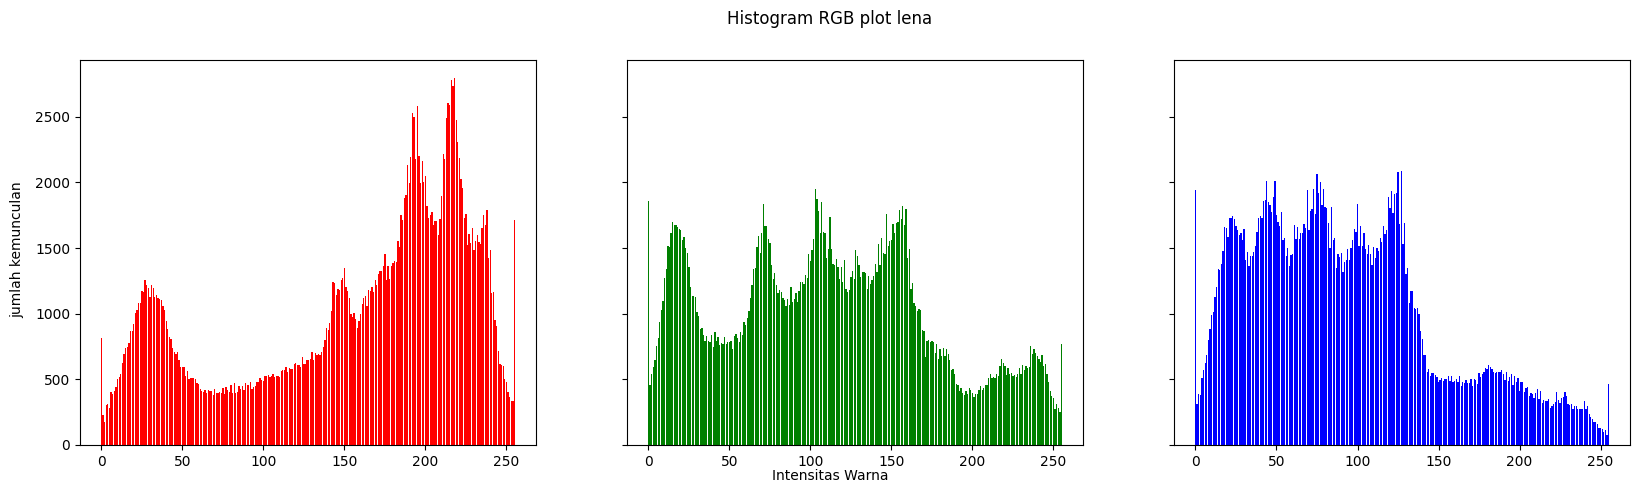

In [ ]:
img = cv.imread('/content/drive/MyDrive/lena.jpeg')

img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256


for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

name = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot lena')
fig.text(0.09, 0.5, 'jumlah kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

<BarContainer object of 256 artists>

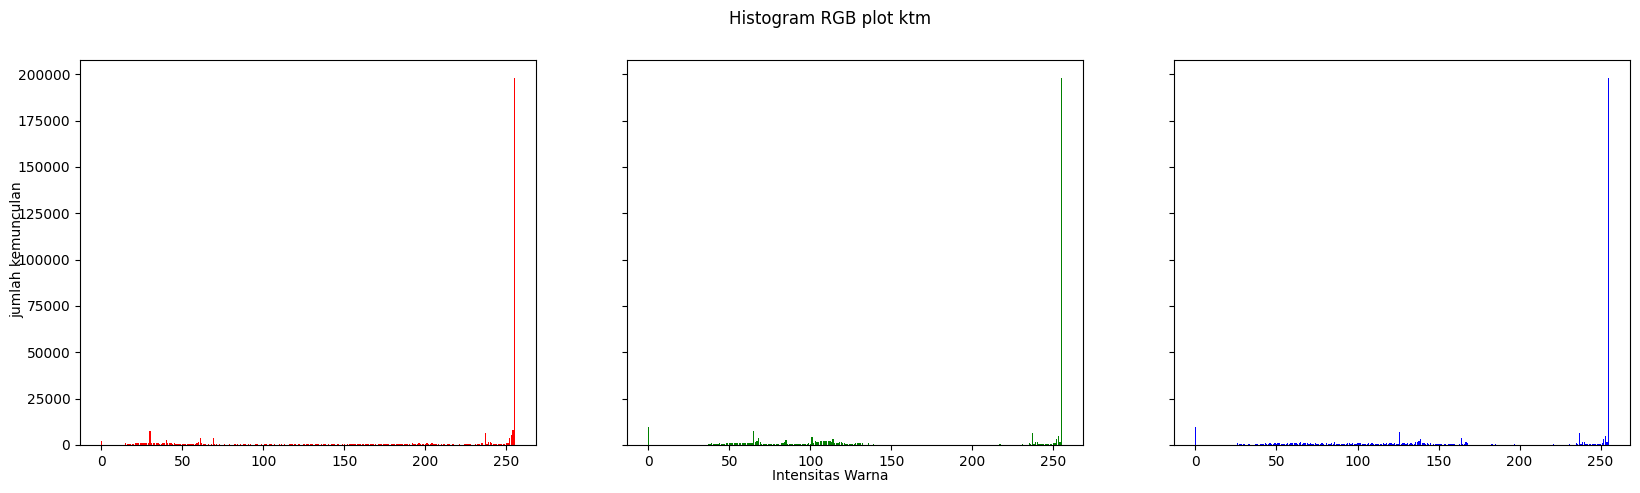

In [ ]:
img = cv.imread('/content/drive/MyDrive/KTM.png')

img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256


for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

name = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot ktm')
fig.text(0.09, 0.5, 'jumlah kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

PERTANYAAN PRAKTIKUM E1

No 1

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

gray = cv.imread('/content/drive/MyDrive/lena.jpeg', cv.IMREAD_GRAYSCALE)

hist_manual = histogram_manual(gray)

hist_np, _ = np.histogram(gray.flatten(), bins=256, range=[0,256])

hist_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

print("Selisih Maks NumPy vs Manual:", np.max(np.abs(hist_np - hist_manual)))
print("Selisih Maks OpenCV vs Manual:", np.max(np.abs(hist_cv - hist_manual)))

Selisih Maks NumPy vs Manual: 0
Selisih Maks OpenCV vs Manual: 0


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

gray = cv.imread('/content/drive/MyDrive/KTM.png', cv.IMREAD_GRAYSCALE)

hist_manual = histogram_manual(gray)

hist_np, _ = np.histogram(gray.flatten(), bins=256, range=[0,256])

hist_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

print("Selisih Maks NumPy vs Manual:", np.max(np.abs(hist_np - hist_manual)))
print("Selisih Maks OpenCV vs Manual:", np.max(np.abs(hist_cv - hist_manual)))

Selisih Maks NumPy vs Manual: 0
Selisih Maks OpenCV vs Manual: 0


No 2

In [ ]:
NIM = '244107020101'

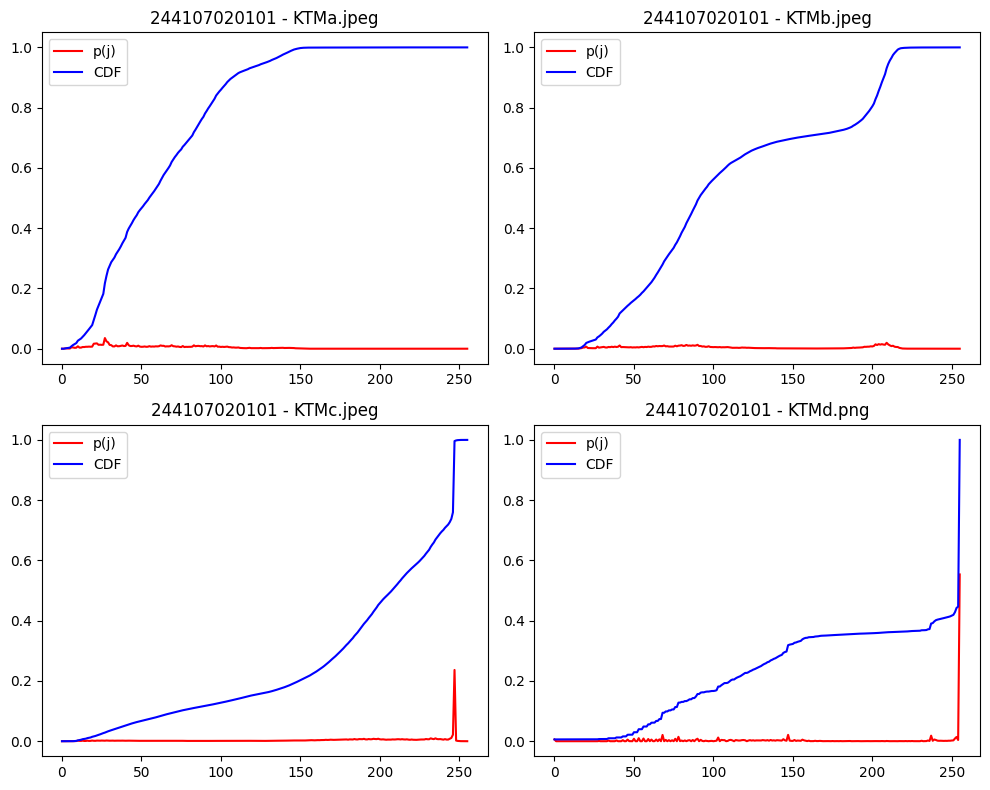

In [ ]:
citra_ktm = ['KTMa.jpeg', 'KTMb.jpeg', 'KTMc.jpeg', 'KTMd.png']
plt.figure(figsize=(10, 8))

for i, nama_file in enumerate(citra_ktm, 1):
    img = cv.imread('/content/drive/MyDrive/' + nama_file, cv.IMREAD_GRAYSCALE)

    hist = histogram_manual(img)
    p = hist / img.size
    cdf = np.cumsum(p)

    plt.subplot(2, 2, i)
    plt.plot(p, color='red', label='p(j)')
    plt.plot(cdf, color='blue', label='CDF')
    plt.title(f'{NIM} - {nama_file}')
    plt.legend()

plt.tight_layout()
plt.show()

Analisis: Citra gelap (KTM1a) akan memiliki kurva CDF yang menanjak curam di sebelah kiri (intensitas rendah), sedangkan citra terang (KTM1d) akan landai di kiri dan menanjak tajam di sebelah kanan.

No 3

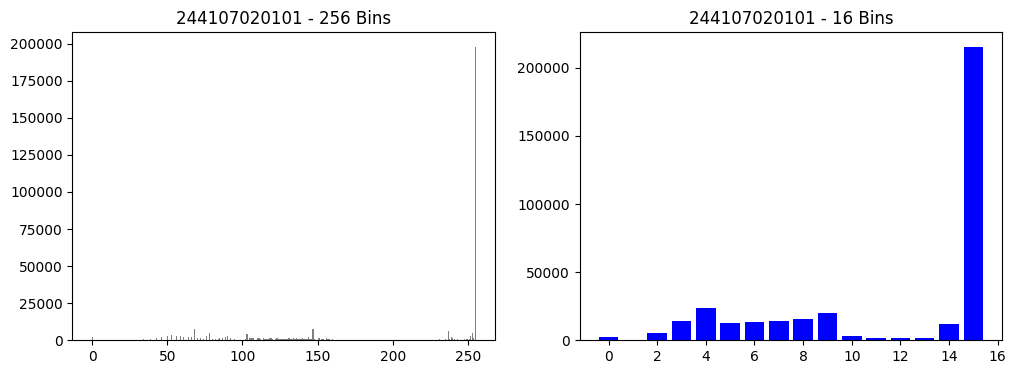

In [ ]:
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}
bins_param = PARAM['bins']
hist_256, _ = np.histogram(gray.flatten(), bins=256, range=[0,256])
hist_param, _ = np.histogram(gray.flatten(), bins=bins_param, range=[0,256])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(np.arange(256), hist_256, color='gray')
axs[0].set_title(f'{NIM} - 256 Bins')
axs[1].bar(np.arange(bins_param), hist_param, color='blue')
axs[1].set_title(f'{NIM} - {bins_param} Bins')
plt.show()

PERCOBAAN HISTOGRAM EQUALIZATION

In [ ]:
def manual_equalize(img):

    hist = np.bincount(img.ravel(), minlength=256)

    cdf = hist.cumsum()

    cdf_nonzero = cdf[cdf > 0]
    cdf_min = cdf_nonzero[0]

    total_pixel = img.size

    lut = np.round(
        (cdf - cdf_min) * 255 / (total_pixel - cdf_min)
    )

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    result = lut[img]

    return result

def bandingkan_equalize(berkas):
    img = cv.imread(berkas, cv.IMREAD_GRAYSCALE)

    manual = manual_equalize(img)

    opencv = cv.equalizeHist(img)

    diff = cv.absdiff(manual, opencv)

    max_diff = diff.max()

    jumlah_beda = np.count_nonzero(diff)

    print("File :", berkas)
    print("Selisih maksimum :", max_diff)
    print("Jumlah pixel berbeda :", jumlah_beda)

    return manual, opencv, diff



In [ ]:
manual_lena, opencv_lena, diff_lena = bandingkan_equalize(
    '/content/drive/MyDrive/lena.jpeg'
)
manual_ktm, opencv_ktm, diff_ktm = bandingkan_equalize(
    '/content/drive/MyDrive/KTMa.jpeg'
)

File : /content/drive/MyDrive/lena.jpeg
Selisih maksimum : 0
Jumlah pixel berbeda : 0
File : /content/drive/MyDrive/KTMa.jpeg
Selisih maksimum : 0
Jumlah pixel berbeda : 0


Berdasarkan hasil pengujian, implementasi histogram equalization secara manual dibandingkan dengan fungsi cv.equalizeHist() menghasilkan selisih maksimum sebesar 0 dan jumlah pixel berbeda sebesar 0, baik pada citra lena.jpeg maupun KTMa.jpeg. Hal ini menunjukkan bahwa hasil ekualisasi histogram dari implementasi manual identik dengan hasil yang dihasilkan oleh library OpenCV cv.equalizeHist() pada kedua citra tersebut.

Karena selisih maksimum bernilai 0 dan tidak terdapat pixel yang berbeda, maka tidak terdapat perbedaan hasil antara implementasi manual dan cv.equalizeHist() pada pengujian ini. Dengan demikian, pada data yang digunakan, proses perhitungan histogram, CDF, pemetaan intensitas, serta pembulatan yang dilakukan pada implementasi manual menghasilkan nilai yang sama dengan implementasi OpenCV.

## 3 Equalisasi B, G, R

In [ ]:
img3 = cv.imread('/content/drive/MyDrive/lena.jpeg')

kanal = list(cv.split(img3))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

In [ ]:
img3 = cv.imread('/content/drive/MyDrive/KTMa.jpeg')

kanal = list(cv.split(img4))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

4. Equalisasi Y, V, dan L

In [ ]:
ycrcb = cv.cvtColor(img3, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(y),
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

hsv = cv.cvtColor(img3, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)

he_v = cv.cvtColor(
    cv.merge([
        h,
        sat,
        cv.equalizeHist(v)
    ]),
    cv.COLOR_HSV2BGR
)

lab = cv.cvtColor(img3, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)

he_l = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(l),
        a,
        b
    ]),
    cv.COLOR_LAB2BGR
)

tampilkan kelimanya:

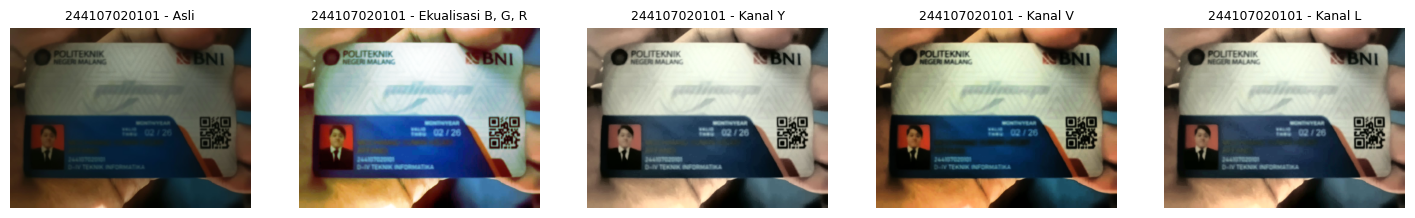

In [ ]:
judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [
    img3,
    he_rgb,
    he_y,
    he_v,
    he_l
]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):

    plt.subplot(1, 5, i)

    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))

    plt.title(NIM + ' - ' + t, fontsize=9)

    plt.axis('off')

plt.show()

Mengukur pergeseran Hue

In [ ]:
def geser_hue(asli, hasil):

    h1 = cv.cvtColor(
        asli,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    h2 = cv.cvtColor(
        hasil,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    d = np.minimum(d, 180 - d)

    return d.mean()

In [ ]:
print(
    '%-22s %16s %16s'
    % (
        'Cara',
        'geser Hue (der)',
        'rerata terang'
    )
)

for t, c in zip(judul, citra):

    print(
        '%-22s %16.2f %16.1f'
        % (
            t,
            geser_hue(img3, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        )
    )

Cara                    geser Hue (der)    rerata terang
Asli                               0.00             60.5
Ekualisasi B, G, R                46.74            128.6
Kanal Y                            0.44            128.6
Kanal V                            1.09            105.7
Kanal L                            3.63            122.7


tabel tugas

In [ ]:
print("=" * 75)
print(f"{'Cara':<25} {'Geser Hue (°)':>15} {'Rerata terang':>15}")
print("=" * 75)

hasil_tabel = []

for t, c in zip(judul, citra):

    hue_shift = geser_hue(img3, c) * 2

    brightness = cv.cvtColor(
        c,
        cv.COLOR_BGR2GRAY
    ).mean()

    hasil_tabel.append([
        t,
        hue_shift,
        brightness
    ])

    print(
        f"{t:<25} "
        f"{hue_shift:>15.2f} "
        f"{brightness:>15.1f}"
    )

Cara                        Geser Hue (°)   Rerata terang
Asli                                 0.00            60.5
Ekualisasi B, G, R                  46.74           128.6
Kanal Y                              0.44           128.6
Kanal V                              1.09           105.7
Kanal L                              3.63           122.7


In [ ]:
for i in range(1, len(hasil_tabel)):

    print(
        hasil_tabel[i][0],
        "->",
        f"{hasil_tabel[i][1]:.2f}°"
    )

terbesar = max(
    hasil_tabel[1:],
    key=lambda x: x[1]
)

print()
print(
    "Pergeseran Hue terbesar:",
    terbesar[0],
    f"({terbesar[1]:.2f}°)"
)

Ekualisasi B, G, R -> 46.74°
Kanal Y -> 0.44°
Kanal V -> 1.09°
Kanal L -> 3.63°

Pergeseran Hue terbesar: Ekualisasi B, G, R (46.74°)


# **Pertanyaan**

**Soal**
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.
3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.


**Jawaban**

1.Berdasarkan hasil pengukuran, metode Ekualisasi B, G, R menghasilkan pergeseran Hue paling besar, yaitu sebesar 46.74° pada citra KTMa.jpeg.


2.Ekualisasi kanal terang tidak menghasilkan pergeseran Hue yang benar-benar nol karena proses konversi ruang warna dan pengembalian citra ke BGR melibatkan pembulatan serta pemotongan nilai (clipping) pada representasi integer 8-bit. Setelah kanal terang diekualisasi, kombinasi kanal terang dan kanal warna dapat menghasilkan nilai BGR yang sedikit berbeda dari citra awal. Ketika nilai tersebut dikonversi kembali ke HSV, perubahan kecil tersebut dapat menyebabkan nilai Hue ikut berubah. Oleh karena itu, meskipun kanal Cr-Cb, Saturation, atau kanal warna pada LAB tidak diubah secara langsung, pergeseran Hue kecil masih dapat terjadi.


3.Berdasarkan hasil pengamatan dan nilai pergeseran Hue, metode Ekualisasi B,G,R pada LAB dipilih karena mampu meningkatkan detail pada bagian foto dengan perubahan warna yang relatif kecil. Pada bagian tulisan polinema kontras antara objek dan latar juga terlihat lebih jelas dibandingkan hasil lainnya.


Jawaban soal no 4 :

Hasil perbandingan:
----------------------------------------
LAB + equalizeHist
Geser Hue     : 3.63°
Rerata terang : 122.67

LAB + CLAHE
Geser Hue     : 3.41°
Rerata terang : 89.83


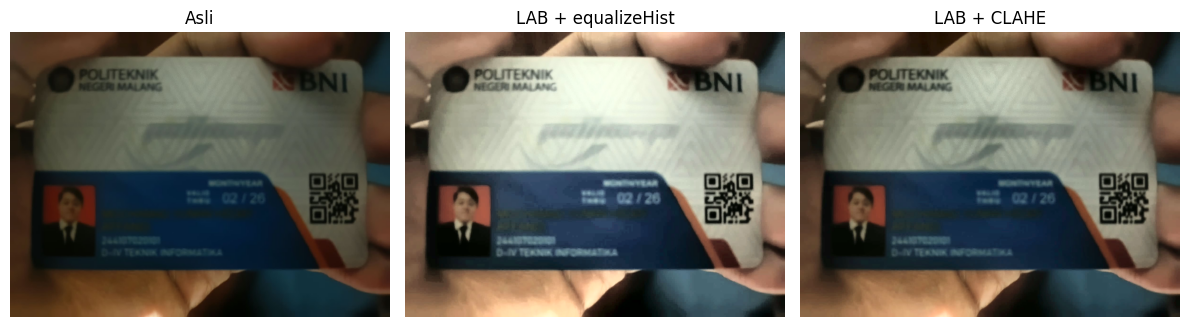

In [ ]:
#membuat clahe
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(
        PARAM['tile'],
        PARAM['tile']
    )
)
#gunakan kanal l lab
lab = cv.cvtColor(
    img3,
    cv.COLOR_BGR2LAB
)

l, a, b = cv.split(lab)

# CLAHE pada kanal L
l_clahe = clahe.apply(l)

he_l_clahe = cv.cvtColor(
    cv.merge([l_clahe, a, b]),
    cv.COLOR_LAB2BGR
)

#bandingkan dengan he_l
hue_he_l = geser_hue(img3, he_l) * 2
hue_clahe = geser_hue(img3, he_l_clahe) * 2

bright_he_l = cv.cvtColor(
    he_l,
    cv.COLOR_BGR2GRAY
).mean()

bright_clahe = cv.cvtColor(
    he_l_clahe,
    cv.COLOR_BGR2GRAY
).mean()

print("Hasil perbandingan:")
print("----------------------------------------")
print(f"LAB + equalizeHist")
print(f"Geser Hue     : {hue_he_l:.2f}°")
print(f"Rerata terang : {bright_he_l:.2f}")

print()

print(f"LAB + CLAHE")
print(f"Geser Hue     : {hue_clahe:.2f}°")
print(f"Rerata terang : {bright_clahe:.2f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))
plt.title('Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(he_l, cv.COLOR_BGR2RGB))
plt.title('LAB + equalizeHist')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(he_l_clahe, cv.COLOR_BGR2RGB))
plt.title('LAB + CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

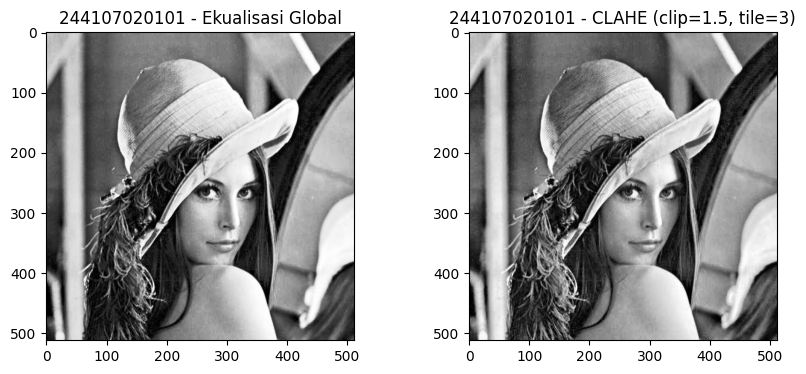

In [ ]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe = clahe.apply(img_gelap)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(he_cv, cmap='gray')
plt.title(f"{NIM} - Ekualisasi Global")
plt.subplot(1, 2, 2)
plt.imshow(img_clahe, cmap='gray')
plt.title(f"{NIM} - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
plt.show()

# E-3: Tugas Praktikum Dithering

1.

In [76]:
def floyd_steinberg_gray(gray, L=2):
    # Simpan sebagai float32 agar perhitungan error tidak overflow/underflow
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Distribusi error ke tetangga yang belum diproses
            if x + 1 < W:
                img[y, x + 1] += error * (7.0 / 16.0)
            if x - 1 >= 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3.0 / 16.0)
            if y + 1 < H:
                img[y + 1, x] += error * (5.0 / 16.0)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1.0 / 16.0)

    # Batasi ke rentang 0-255 lalu kembalikan ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_color(bgr, L=2):
    # Pisahkan tiap kanal B, G, R, lalu proses satu per satu
    channels = cv.split(bgr)
    dithered_channels = [floyd_steinberg_gray(ch, L=L) for ch in channels]
    return cv.merge(dithered_channels)



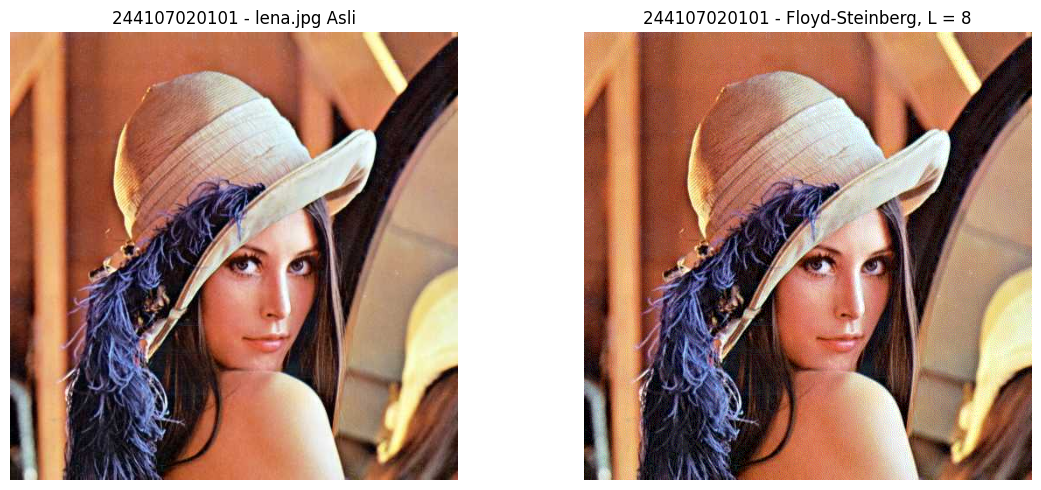

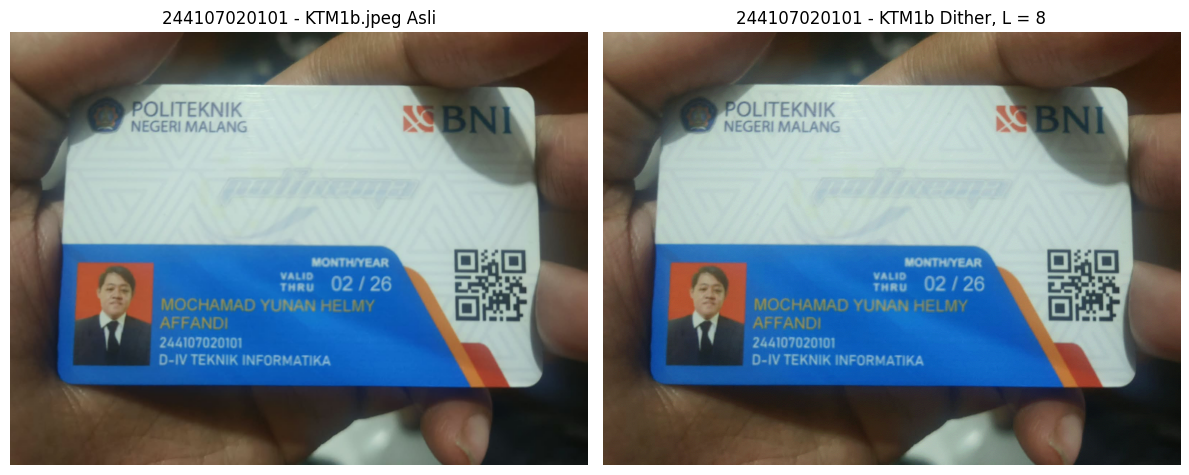

In [79]:
# Tentukan jalur file (sesuaikan ekstensi file KTM Anda di Google Drive)
path_lena = '/content/drive/MyDrive/lena.jpeg'
path_ktm1b = '/content/drive/MyDrive/KTMb.jpeg'

# --- TAHAP 1: Citra Contoh lena.jpg ---
lena_bgr = cv.imread(path_lena)
lena_dither = floyd_steinberg_color(lena_bgr, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
axs[0].set_title(f"{NIM} - lena.jpg Asli")
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
axs[1].set_title(f"{NIM} - Floyd-Steinberg, L = {PARAM['L']}")
axs[1].axis('off')
plt.tight_layout()
plt.show()

# --- TAHAP 2: Citra KTM1b.jpeg ---
ktm1b_bgr = cv.imread(path_ktm1b)
if ktm1b_bgr is not None:
    ktm1b_dither = floyd_steinberg_color(ktm1b_bgr, L=PARAM['L'])

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title(f"{NIM} - KTM1b.jpeg Asli")
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
    axs[1].set_title(f"{NIM} - KTM1b Dither, L = {PARAM['L']}")
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"Gagal memuat: {path_ktm1b}")

2.

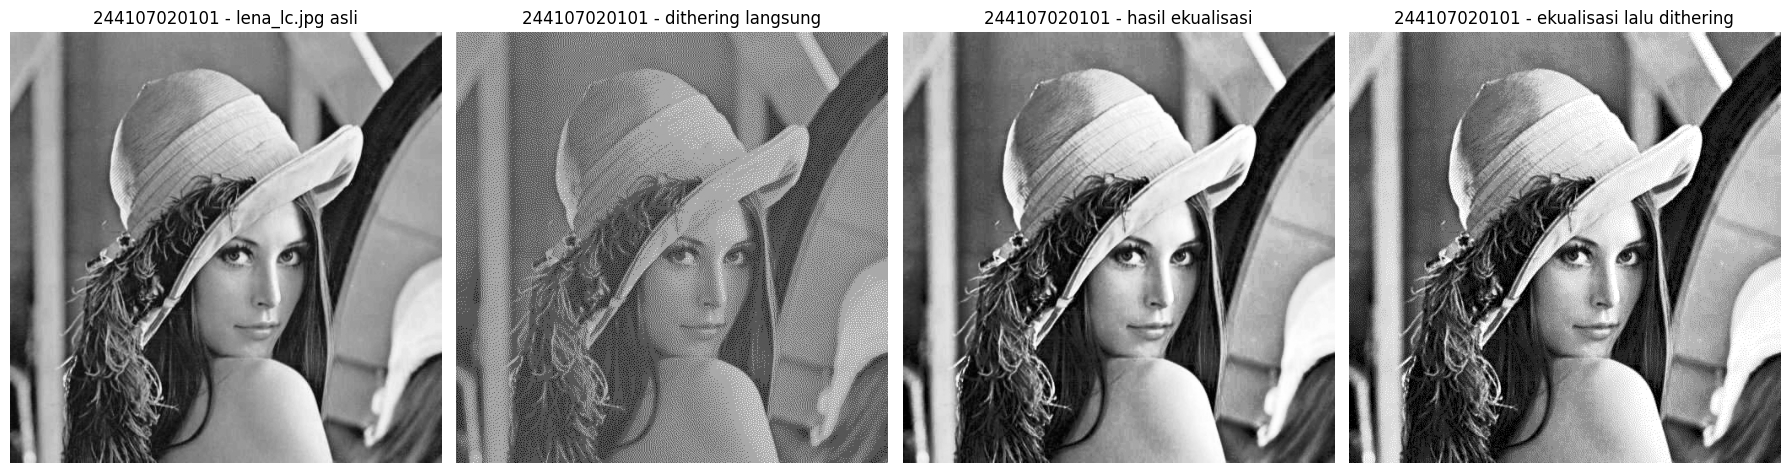

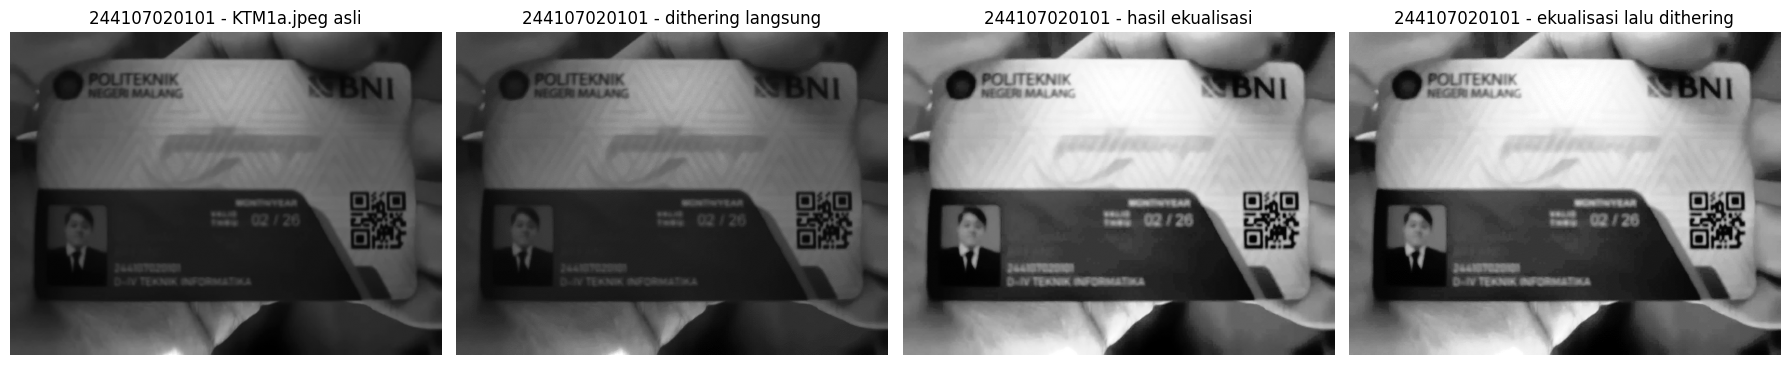

In [81]:
path_lena_lc = '/content/drive/MyDrive/lena_lc.jpeg'
path_ktm1a = '/content/drive/MyDrive/KTMa.jpeg'

def proses_dan_tampilkan_e3_no2(path_img, label_citra):
    img_gray = cv.imread(path_img, cv.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Berkas {path_img} tidak ditemukan!")
        return

    # 1. Dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg_gray(img_gray, L=PARAM['L'])

    # 2. Histogram Equalization terlebih dahulu
    img_he = cv.equalizeHist(img_gray)

    # 3. Dithering setelah ekualisasi
    dither_setelah_he = floyd_steinberg_gray(img_he, L=PARAM['L'])

    # Tampilkan 4 panel berdampingan sesuai petunjuk modul
    fig, axs = plt.subplots(1, 4, figsize=(18, 5))

    axs[0].imshow(img_gray, cmap='gray')
    axs[0].set_title(f"{NIM} - {label_citra} asli")
    axs[0].axis('off')

    axs[1].imshow(dither_langsung, cmap='gray')
    axs[1].set_title(f"{NIM} - dithering langsung")
    axs[1].axis('off')

    axs[2].imshow(img_he, cmap='gray')
    axs[2].set_title(f"{NIM} - hasil ekualisasi")
    axs[2].axis('off')

    axs[3].imshow(dither_setelah_he, cmap='gray')
    axs[3].set_title(f"{NIM} - ekualisasi lalu dithering")
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

# Tahap 1: Verifikasi pada lena_lc.jpg
proses_dan_tampilkan_e3_no2(path_lena_lc, 'lena_lc.jpg')

# Tahap 2: Terapkan pada KTM1a.jpeg (ruangan gelap)
proses_dan_tampilkan_e3_no2(path_ktm1a, 'KTM1a.jpeg')